<a href="https://colab.research.google.com/github/Nedhu18/-customer-churn-prediction-for-the-Data-Science-Analytics-team-at-Lloyds-Banking-Group./blob/main/Lloyds_Simulation_task_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
 5   Churn          1000 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 47.0+ KB
None

Statistical Summary:
        CustomerID          Age        Churn
count  1000.000000  1000.000000  1000.000000
mean    500.500000    43.267000     0.430000
std     288.819436    15.242311     0.495323
min       1.000000    18.000000     0.000000
25%     250.750000    30.000000     0.000000
50%     500.500000    43.000000     0.000000
75%     750.250000    56.000000     1.000000
max    1000.000000    69.000000     1.000000


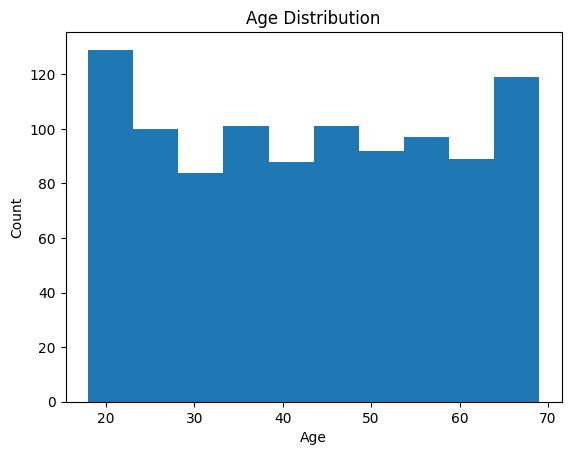

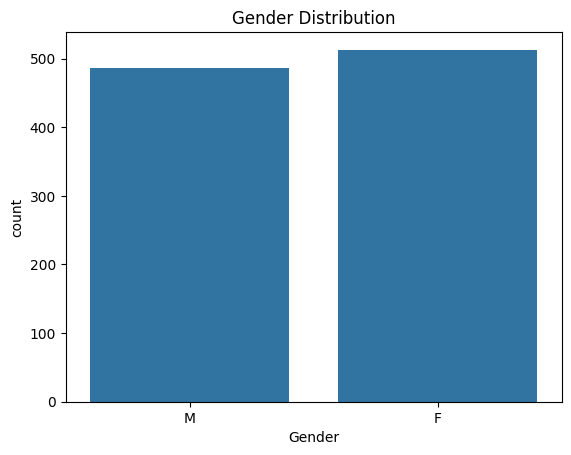

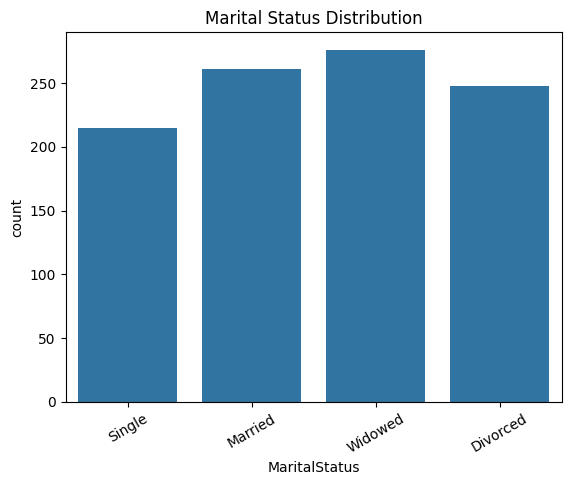

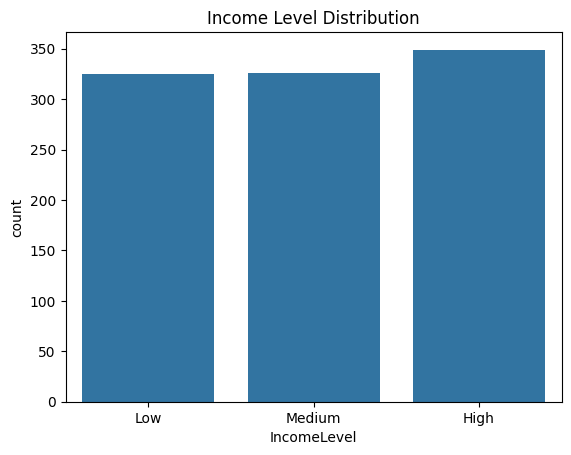

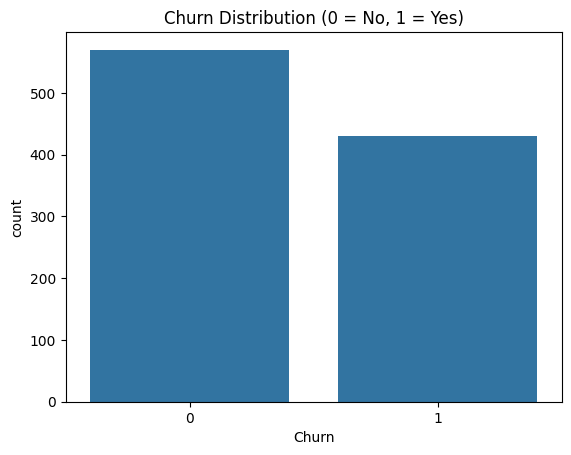


Final Processed Dataset:
        Age  Churn  Gender_M  MaritalStatus_Married  MaritalStatus_Single  \
0  1.229628      1      True                  False                  True   
1  1.426547      0      True                   True                 False   
2 -1.658518      1      True                  False                  True   
3 -1.461599      1      True                  False                 False   
4 -1.461599      1      True                  False                 False   

   MaritalStatus_Widowed  IncomeLevel_Low  IncomeLevel_Medium  
0                  False             True               False  
1                  False             True               False  
2                  False             True               False  
3                   True             True               False  
4                  False            False                True  


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel("Customer_Churn_Data_Large.xlsx")

# -----------------------------
# 1. CREATE CHURN COLUMN
# -----------------------------

def assign_churn(row):
    if row['Age'] < 30 and row['IncomeLevel'] == 'Low':
        return 1
    elif row['MaritalStatus'] == 'Single' and row['IncomeLevel'] == 'Low':
        return 1
    elif row['IncomeLevel'] == 'High' and row['MaritalStatus'] == 'Married':
        return 0
    else:
        return np.random.choice([0,1], p=[0.6, 0.4])  # slight bias to non-churn

df['Churn'] = df.apply(assign_churn, axis=1)

# -----------------------------
# 2. BASIC EDA
# -----------------------------

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# 3. VISUALIZATIONS
# -----------------------------

# Histogram - Age
plt.figure()
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Bar Plot - Gender
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Bar Plot - Marital Status
plt.figure()
sns.countplot(x='MaritalStatus', data=df)
plt.title("Marital Status Distribution")
plt.xticks(rotation=30)
plt.show()

# Bar Plot - Income Level
plt.figure()
sns.countplot(x='IncomeLevel', data=df)
plt.title("Income Level Distribution")
plt.show()

# Churn Distribution
plt.figure()
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.show()

# -----------------------------
# 4. DATA PREPROCESSING
# -----------------------------

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['Gender', 'MaritalStatus', 'IncomeLevel'], drop_first=True)

# Scale Age
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encoded['Age'] = scaler.fit_transform(df_encoded[['Age']])

# Drop CustomerID (not useful for model)
df_encoded = df_encoded.drop(columns=['CustomerID'])

# -----------------------------
# 5. FINAL DATASET
# -----------------------------

print("\nFinal Processed Dataset:")
print(df_encoded.head())

# Save cleaned dataset
df_encoded.to_csv("Cleaned_Churn_Dataset.csv", index=False)

In [3]:
# -----------------------------
# 6. TRAIN-TEST SPLIT
# -----------------------------

from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7. MODEL 1: LOGISTIC REGRESSION
# -----------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# -----------------------------
# 8. MODEL 2: RANDOM FOREST
# -----------------------------

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# -----------------------------
# 9. MODEL 3: XGBOOST
# -----------------------------

from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Logistic Regression Accuracy: 0.695
[[93 24]
 [37 46]]
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       117
           1       0.66      0.55      0.60        83

    accuracy                           0.69       200
   macro avg       0.69      0.67      0.68       200
weighted avg       0.69      0.69      0.69       200

Random Forest Accuracy: 0.6
[[75 42]
 [38 45]]
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       117
           1       0.52      0.54      0.53        83

    accuracy                           0.60       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.60      0.60      0.60       200



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.645
[[80 37]
 [34 49]]
              precision    recall  f1-score   support

           0       0.70      0.68      0.69       117
           1       0.57      0.59      0.58        83

    accuracy                           0.65       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.65      0.65      0.65       200



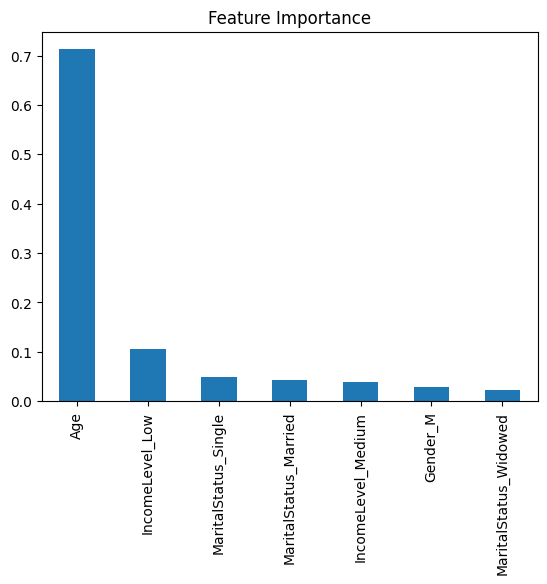

In [4]:
# Feature Importance from Random Forest

import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

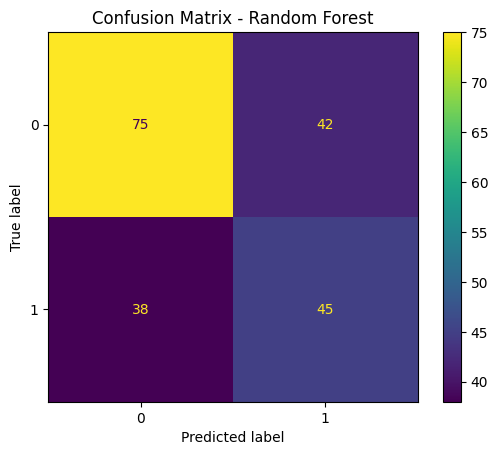

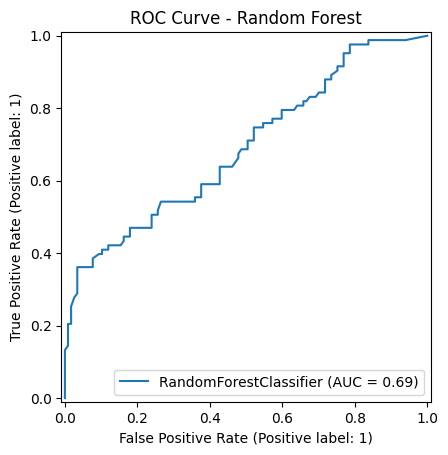

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Confusion Matrix (Random Forest)
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()